In [1]:
import matplotlib.pyplot as plt
from model_wrapper import *

# of Training Instances: 50
# of Testing Instances: 8
Current RAM usage: 299.62 MB


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

def plot_count(train_set, test_set):
    msss_ = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.35, random_state=42)
    Y = train_set[target_columns].values

    # Pass Y as a dummy X since you only care about splitting the labels
    train_index, test_index = next(msss_.split(X=Y, y=Y))

    y_train, y_validation = Y[train_index], Y[test_index]

    # Add axis=0 to get the sum for each column
    train_sums = y_train.sum(axis=0)
    validation_sums = y_validation.sum(axis=0)
    test_sums = [test_set[t].sum() for t in target_columns]

    # Set up the grouped bar locations
    labels = [f"{t} Count" for t in target_columns]
    x = np.arange(len(labels))

    # Set a smaller width to fit 3 bars side-by-side
    width = 0.25

    plt.figure(figsize=(10, 6))

    # Plot the 3 bars and assign them to variables
    bar_train = plt.bar(x - width, train_sums, width, color='green', label='Training')
    bar_val = plt.bar(x, validation_sums, width, color='blue', label='Validation')
    bar_test = plt.bar(x + width, test_sums, width, color='red', label='Testing')

    # Add the text values on top of each bar (padding adds slight space above)
    plt.bar_label(bar_train, padding=3)
    plt.bar_label(bar_val, padding=3)
    plt.bar_label(bar_test, padding=3)

    # Chart formatting
    plt.title('Count of target instances')
    plt.ylabel('Count')

    plt.xticks(x, labels, rotation=45, ha='right')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [3]:
paths = ("train_series/" +
         full_df["StudyInstanceUID"] + "/" +
         full_df["SeriesInstanceUID"])
img_count = paths.apply(get_img_count)

full_df["img_count"] = img_count
train_full = full_df[full_df["StudyInstanceUID"].isin(train_ids)]
test_full = full_df[full_df["StudyInstanceUID"].isin(test_ids)]

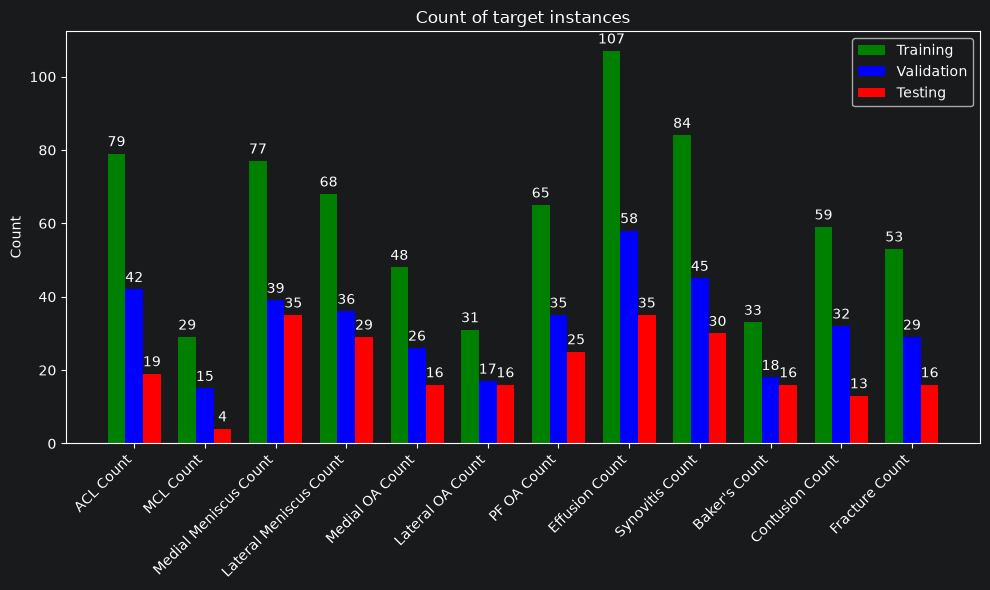

In [4]:
# Plot of count of all instance
plot_count(train_full, test_full)

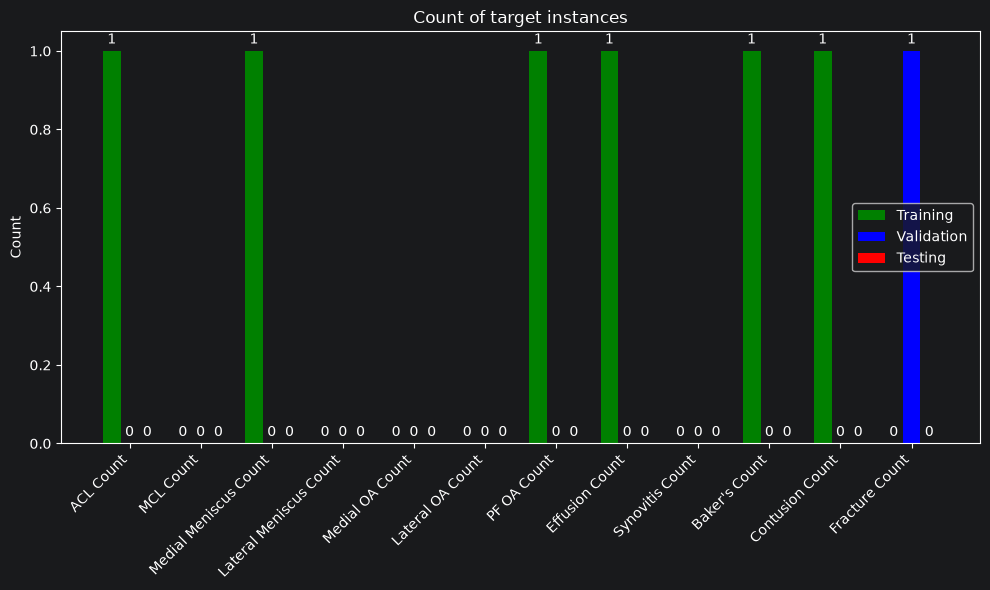

In [5]:
# Count of training / testing data being dropped
plot_count(train_full[train_full["img_count"] < MIN_IMG_COUNT], test_full[test_full["img_count"] < MIN_IMG_COUNT])

Plane: Sagittal


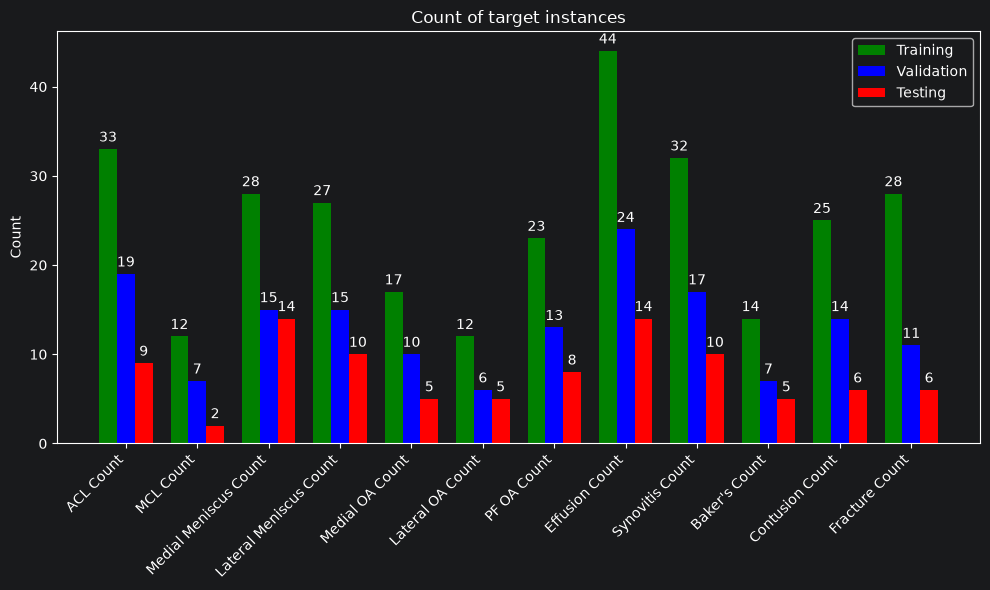

Plane: Axial


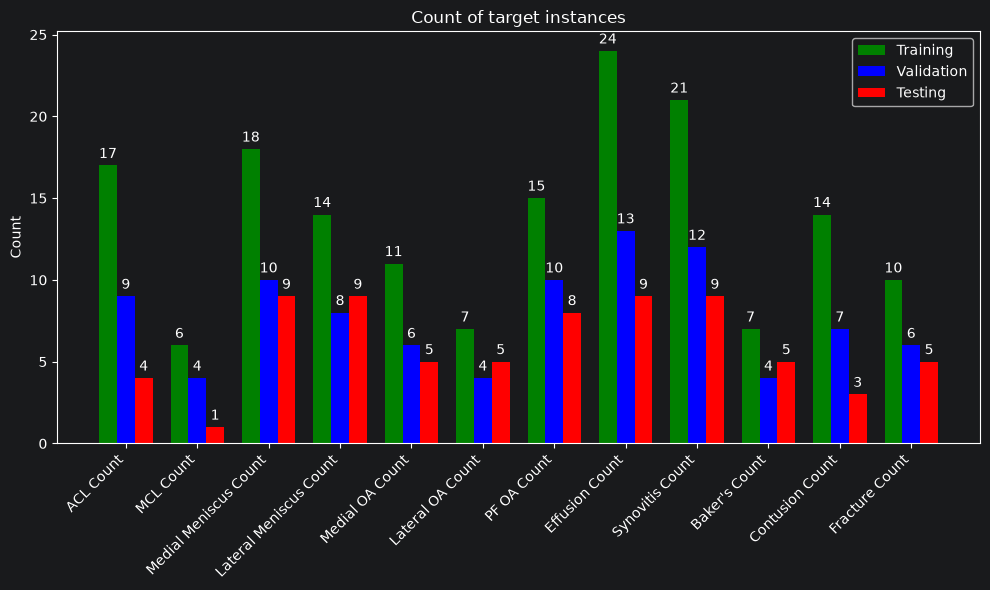

Plane: Coronal


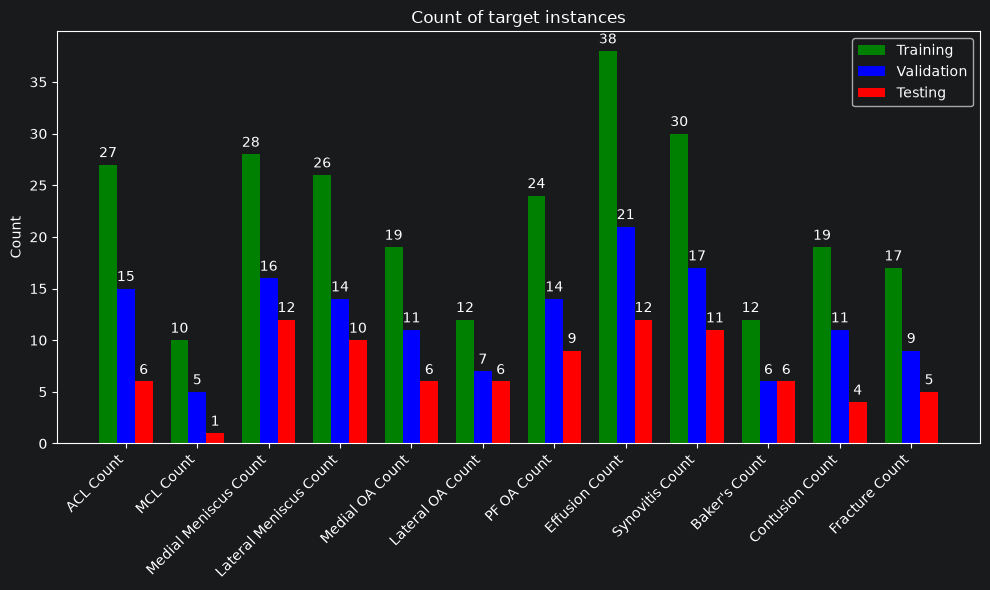

In [6]:
# Plot for each plane
for p in planes:
    print(f"Plane: {p}")
    plot_count(
        train_full[(train_full["img_count"] >= MIN_IMG_COUNT) &
                   (train_full["Anatomical_Plane"] == p)],
        test_full[(test_full["img_count"] >= MIN_IMG_COUNT) &
                   (test_full["Anatomical_Plane"] == p)])

Plane: Sagittal
Fluid Sensitive: 0
Fat Suppression: 0


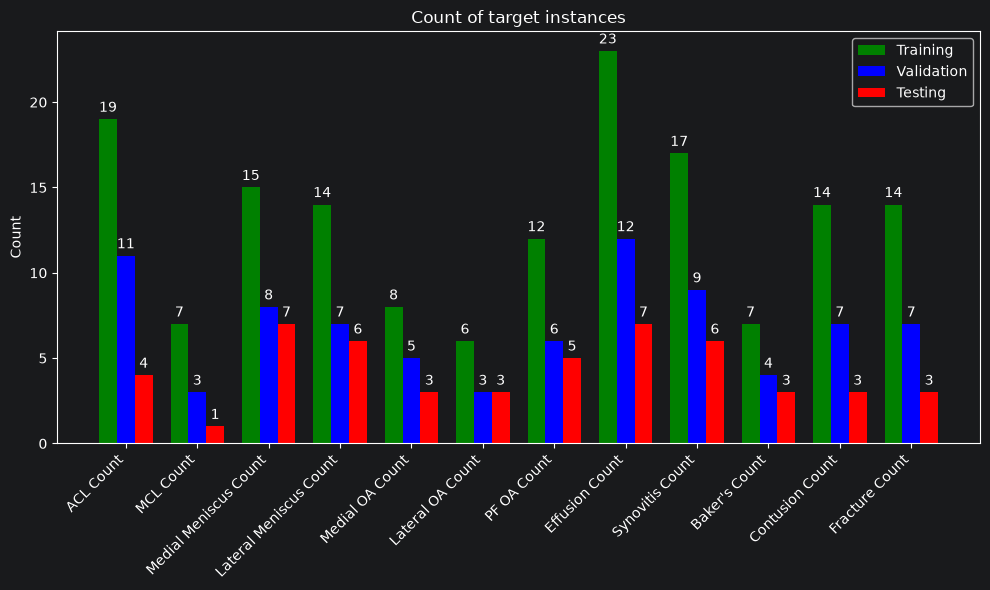

Plane: Sagittal
Fluid Sensitive: 1
Fat Suppression: 1


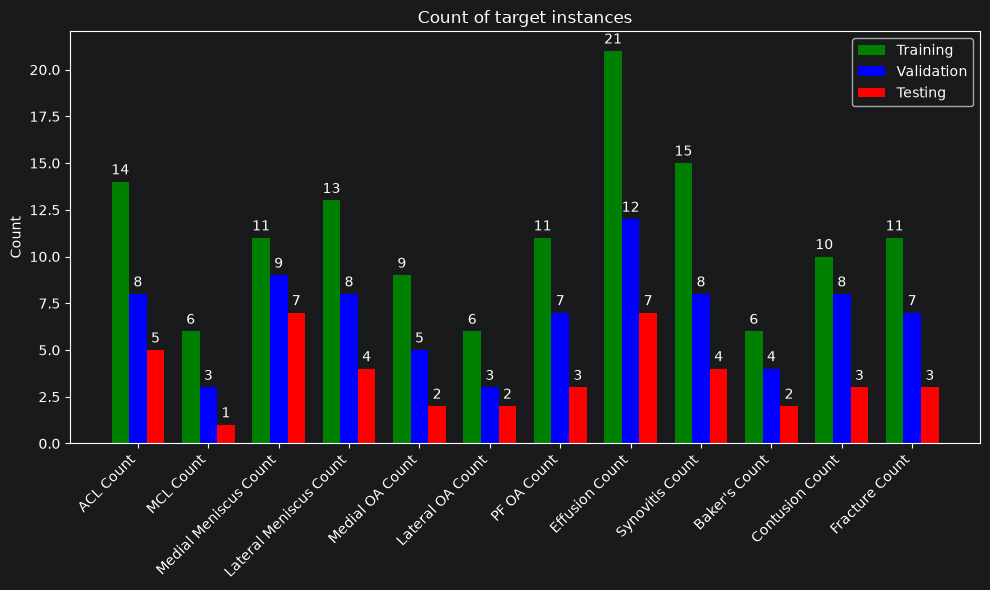

Plane: Axial
Fluid Sensitive: 0
Fat Suppression: 0


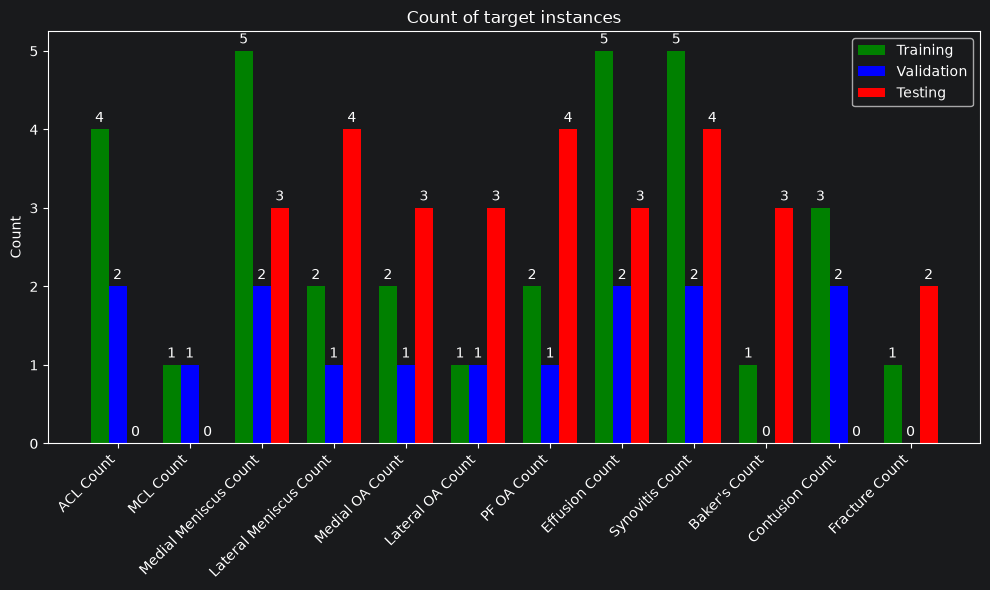

Plane: Axial
Fluid Sensitive: 1
Fat Suppression: 1


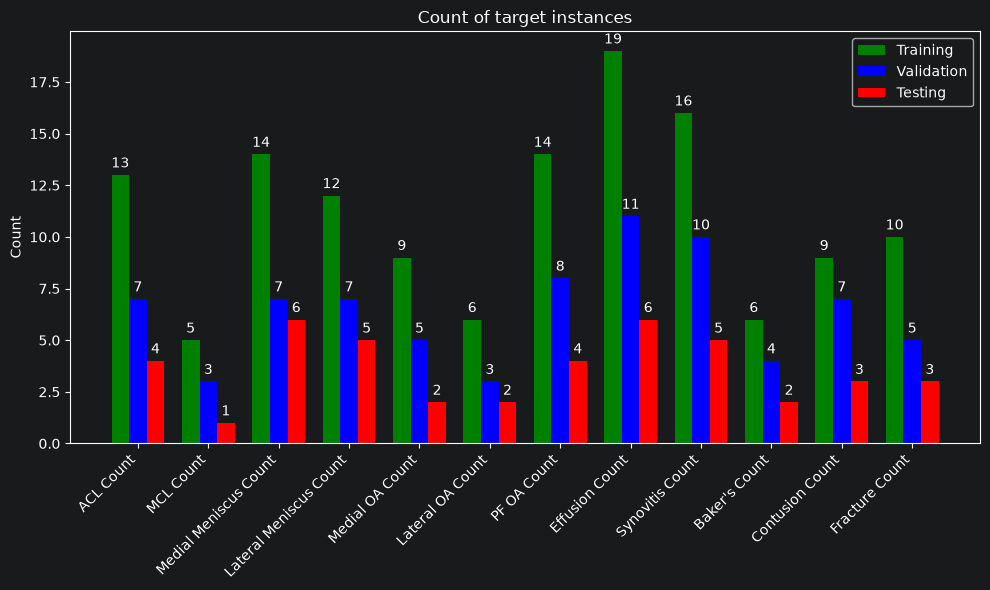

Plane: Coronal
Fluid Sensitive: 0
Fat Suppression: 0


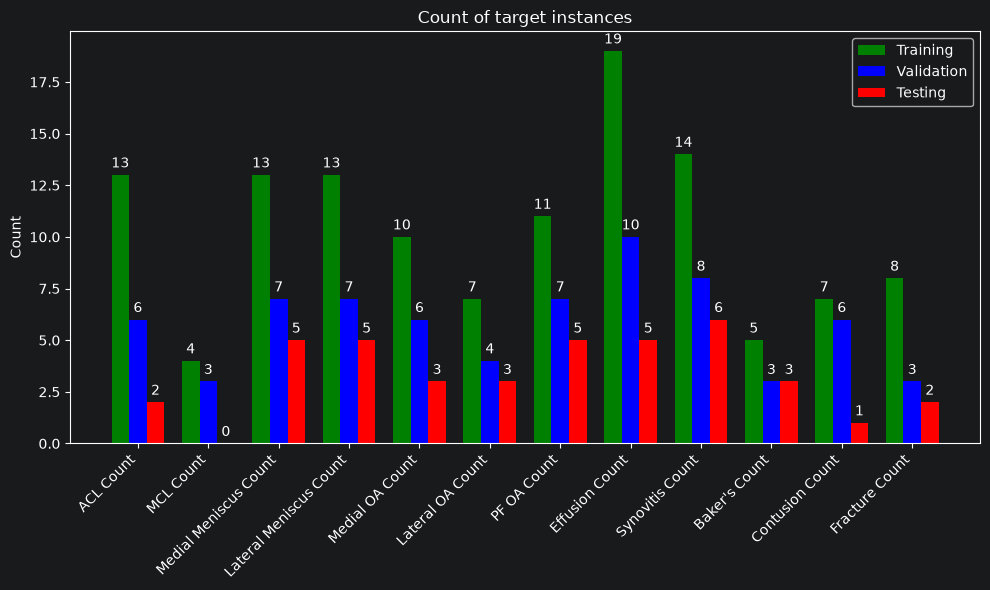

Plane: Coronal
Fluid Sensitive: 1
Fat Suppression: 1


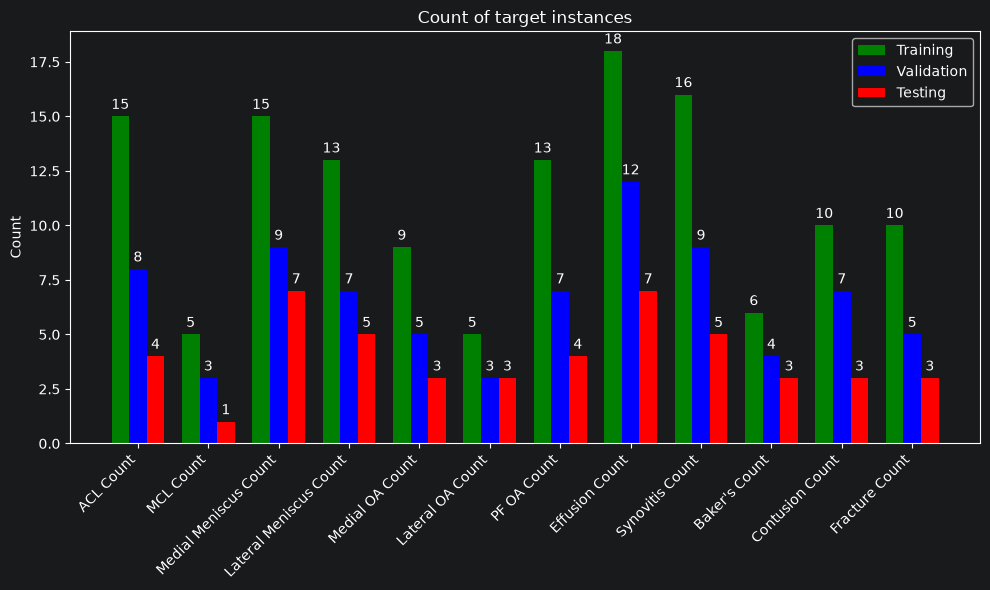

In [7]:
# Plot for every type of model
for p in planes:
    for i in range(2):
        print(f"""Plane: {p}
Fluid Sensitive: {i}
Fat Suppression: {i}""")
        plot_count(
            train_full[
                (train_full["img_count"] >= MIN_IMG_COUNT) &
                (train_full["Anatomical_Plane"] == p) &
                (train_full["Fluid_Sensitive"] == i)],
            test_full[
                (test_full["img_count"] >= MIN_IMG_COUNT) &
                (test_full["Anatomical_Plane"] == p) &
                (test_full["Fluid_Sensitive"] == i)]
        )